In [13]:
import matplotlib.pyplot as plt
import numpy as np

from skfda.datasets import fetch_aemet

X, y = fetch_aemet(return_X_y=True, as_frame=True)
fd = X.iloc[:, 0].array
temperature = fd.coordinates[0]
precipitation = fd.coordinates[1]

In [14]:
low_altitude = X["altitude"] < 250
labels = np.where(low_altitude, "low altitude", "high altitude")
y = np.where(low_altitude, 0, 1)  # 0 = low altitude, 1 = high altitude (binary label)

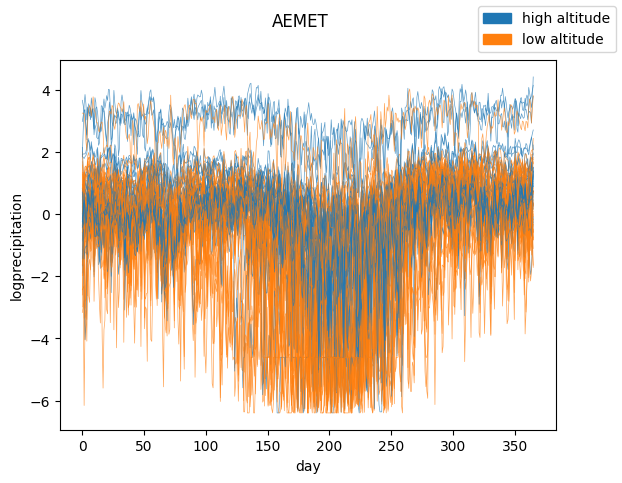

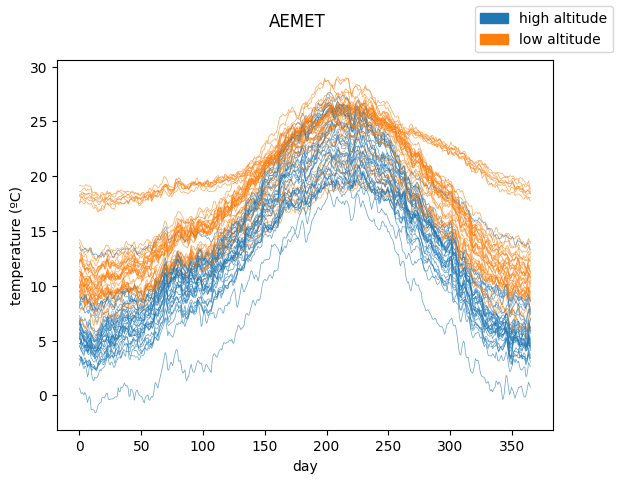

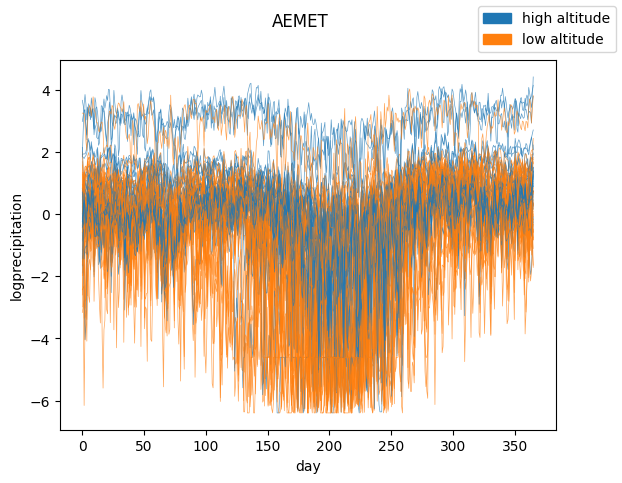

In [15]:
colors = {
    "low altitude": "red",
    "high altitude": "blue",
}

temperature.plot(
    group=labels,
    linewidth=0.5,
    alpha=0.7,
    legend=True,
)

precipitation.plot(
    group=labels,
    linewidth=0.5,
    alpha=0.7,
    legend=True,
)

In [16]:
max_temp = temperature.data_matrix.max(axis=-1)
max_precip = precipitation.data_matrix.max(axis=-1)

In [17]:
from sklearn.model_selection import train_test_split

(
    temp_train,
    temp_test,
    precip_train,
    precip_test,
    max_temp_train,
    max_temp_test,
    max_precip_train,
    max_precip_test,
    y_train,
    y_test,
) = train_test_split(
    temperature,
    precipitation,
    max_temp,
    max_precip,
    y,
    test_size=0.10,
    stratify=y,
    random_state=42,
)

In [18]:
from skfda.exploratory.stats import root_mean_square_l2

rms_temp = root_mean_square_l2(temp_train)
rms_precip = root_mean_square_l2(precip_train)
temp_train_scaled = temp_train / rms_temp
precip_train_scaled = precip_train / rms_precip
temp_test_scaled = temp_test / rms_temp
precip_test_scaled = precip_test / rms_precip

In [36]:
from sklearn.preprocessing import StandardScaler as SklearnStandardScaler

scaler = SklearnStandardScaler()
scalar_train = scaler.fit_transform(np.column_stack([max_temp_train, max_precip_train]))
scalar_test = scaler.transform(np.column_stack([max_temp_test, max_precip_test]))

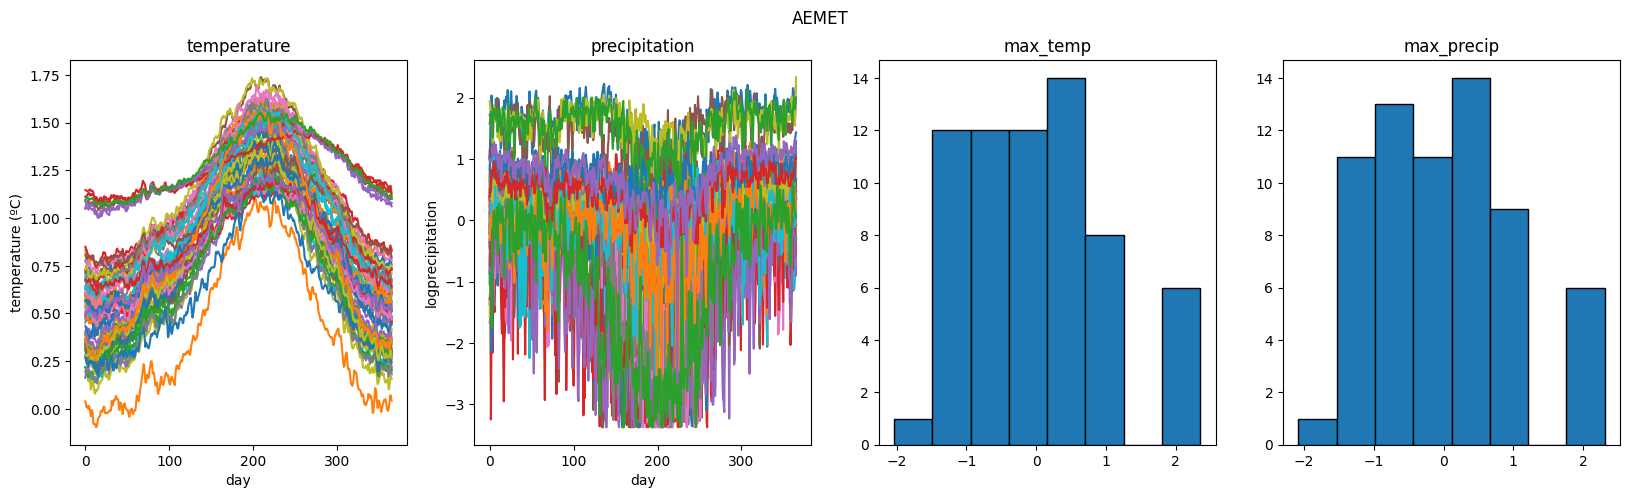

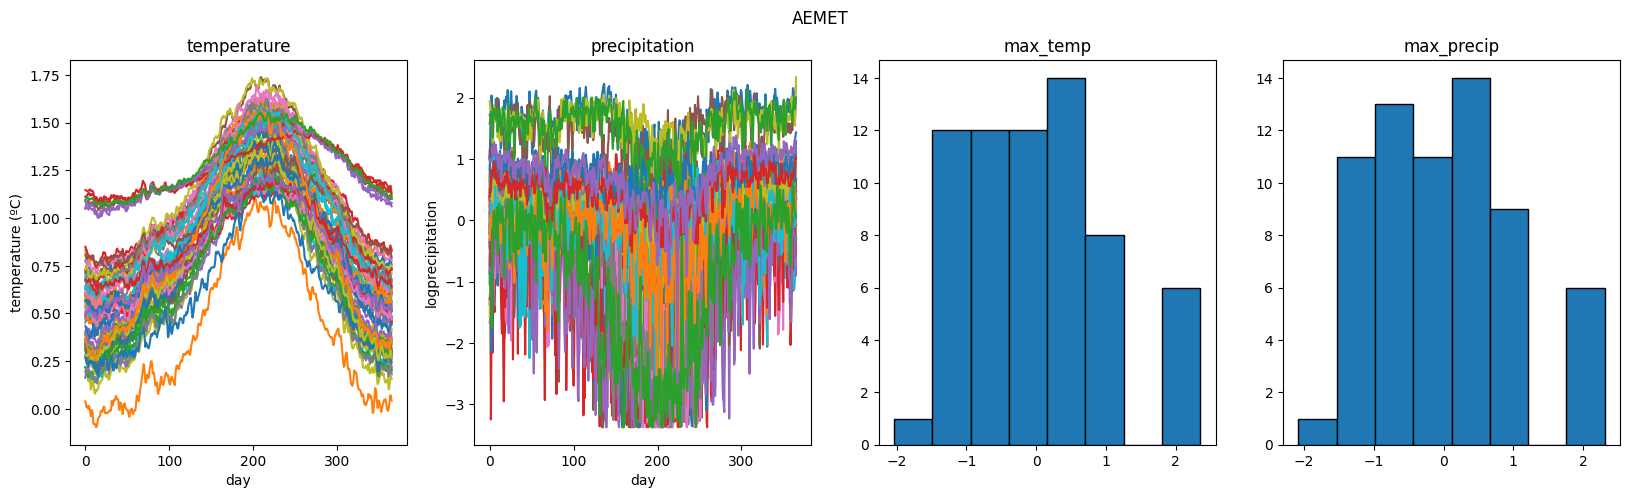

In [20]:
import pandas as pd

from skfda.exploratory.visualization.representation import plot_mixed_data

X_train = pd.DataFrame({
    "temperature": temp_train_scaled,
    "precipitation": precip_train_scaled,
    "max_temp": scalar_train[:, 0],
    "max_precip": scalar_train[:, 1],
})
X_test = pd.DataFrame({
    "temperature": temp_test_scaled,
    "precipitation": precip_test_scaled,
    "max_temp": scalar_test[:, 0],
    "max_precip": scalar_test[:, 1],
})
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

plot_mixed_data(X_train, axes=axes)

In [21]:
from skfda.misc.metrics import PProductMetric, default_metric, l2_distance

metric = PProductMetric(
    p=2,
    metrics=[l2_distance, l2_distance, default_metric, default_metric],
    weights=np.array([1, 1, 5, 5]),
)

In [23]:
from itertools import product

from sklearn.metrics import accuracy_score, make_scorer
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from skfda.ml.classification import KNeighborsClassifier

initial_metric = PProductMetric(
    p=2,
    metrics=[
        l2_distance,
        l2_distance,
        default_metric,
        default_metric,
    ],
    weights=np.array([1, 1, 1, 1]),  # initial
)

knn = KNeighborsClassifier(n_neighbors=5, metric=initial_metric)

param_distributions = {
    "metric__weights": [
        np.random.dirichlet(np.ones(4))  # uniform over 4-dimensional simplex
        for _ in range(3000)  # generate 1000 weight vectors in the simplex
    ],
}
random_search = RandomizedSearchCV(
    estimator=knn,
    param_distributions=param_distributions,
    n_iter=1000,  # number of random samples you want to test
    cv=5,
    scoring=make_scorer(accuracy_score),
    verbose=1,
    random_state=42,
)

random_search.fit(X_train, y_train)

print("Best weights:", random_search.best_params_["metric__weights"])
print("Best CV accuracy:", random_search.best_score_)

y_pred = random_search.best_estimator_.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.2%}")

Fitting 5 folds for each of 1000 candidates, totalling 5000 fits
Best weights: [0.24887239 0.01043847 0.30915918 0.43152996]
Best CV accuracy: 0.9384615384615385
Test accuracy: 87.50%


In [24]:
y_pred = random_search.best_estimator_.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.2%}")

Test accuracy: 87.50%


In [25]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(temp_train, y_train)

y_pred = knn.predict(temp_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.2%}")

Test accuracy: 87.50%


In [37]:
from skfda.preprocessing.scaler import StandardScaler
from sklearn.neighbors import (
    KNeighborsClassifier as SklearnKNeighborsClassifier,
)

results = {
    "X": [],
    "temperature": [],
    "precipitation": [],
    "max_temp": [],
    "max_precipitation": [],
}


def results_with_seed(seed: int) -> None:
    
    X, y = fetch_aemet(return_X_y=True, as_frame=True)
    fd = X.iloc[:, 0].array
    temperature = fd.coordinates[0]
    precipitation = fd.coordinates[1]

    low_altitude = X["altitude"] < 250
    labels = np.where(low_altitude, "low altitude", "high altitude")
    y = np.where(low_altitude, 0, 1)  # 0 = low altitude, 1 = high altitude (binary label)

    max_temp = temperature.data_matrix.max(axis=-1)
    max_precip = precipitation.data_matrix.max(axis=-1)

    (
        temp_train,
        temp_test,
        precip_train,
        precip_test,
        max_temp_train,
        max_temp_test,
        max_precip_train,
        max_precip_test,
        y_train,
        y_test,
    ) = train_test_split(
        temperature,
        precipitation,
        max_temp,
        max_precip,
        y,
        test_size=0.10,
        stratify=y,
        random_state=42,
    )

    rms_temp = root_mean_square_l2(temp_train)
    rms_precip = root_mean_square_l2(precip_train)
    temp_train_scaled = temp_train / rms_temp
    precip_train_scaled = precip_train / rms_precip
    temp_test_scaled = temp_test / rms_temp
    precip_test_scaled = precip_test / rms_precip

    scaler = SklearnStandardScaler()
    scalar_train = scaler.fit_transform(np.column_stack([max_temp_train, max_precip_train]))
    scalar_test = scaler.transform(np.column_stack([max_temp_test, max_precip_test]))

    X_train = pd.DataFrame({
        "temperature": temp_train_scaled,
        "precipitation": precip_train_scaled,
        "max_temp": scalar_train[:, 0],
        "max_precip": scalar_train[:, 1],
    })
    X_test = pd.DataFrame({
        "temperature": temp_test_scaled,
        "precipitation": precip_test_scaled,
        "max_temp": scalar_test[:, 0],
        "max_precip": scalar_test[:, 1],
    })

    initial_metric = PProductMetric(
        p=2,
        metrics=[
            l2_distance,
            l2_distance,
            default_metric,
            default_metric,
        ],
        weights=np.array([0.24887239, 0.01043847, 0.30915918, 0.43152996]),
    )

    knn = KNeighborsClassifier(n_neighbors=5, metric=initial_metric)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    results["X"].append(accuracy_score(y_test, y_pred))

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(temp_train, y_train)

    y_pred = knn.predict(temp_test)

    results["temperature"].append(accuracy_score(y_test, y_pred))

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(precip_train, y_train)

    y_pred = knn.predict(precip_test)

    results["precipitation"].append(accuracy_score(y_test, y_pred))


    water_df_train = pd.DataFrame({"max_temp": scalar_train[:, 0]})
    water_df_test = pd.DataFrame({"max_temp": scalar_test[:, 0]})
    knn = SklearnKNeighborsClassifier(n_neighbors=5)
    knn.fit(water_df_train, y_train)
    y_pred = knn.predict(water_df_test)
    results["max_temp"].append(accuracy_score(y_test, y_pred))

    water_df_train = pd.DataFrame({"max_precipitation": scalar_train[:, 1]})
    water_df_test = pd.DataFrame({"max_precipitation": scalar_test[:, 1]})
    knn = SklearnKNeighborsClassifier(n_neighbors=5)
    knn.fit(water_df_train, y_train)
    y_pred = knn.predict(water_df_test)
    results["max_precipitation"].append(accuracy_score(y_test, y_pred))




In [38]:
for i in range(20):
    results_with_seed(i)

# Summarize
for key in results:
    accs = np.array(results[key])
    print(f"{key}: {accs.mean():.3f} ± {accs.std():.3f}")

X: 0.875 ± 0.000
temperature: 0.875 ± 0.000
precipitation: 0.750 ± 0.000
max_temp: 0.875 ± 0.000
max_precipitation: 0.875 ± 0.000
